# Fiber photometry in Spyglass

This notebook reads the Hanks lab's fiber photometry data back out of a Spyglass database and works with it. It uses only the tables from the draft fiber-photometry schema, `spyglass.common.common_photometry` ([LorenFrankLab/spyglass PR #1637](https://github.com/LorenFrankLab/spyglass/pull/1637)). The sessions were loaded with `spyglass/insert_fiber_photometry.py`.


**Where the data lives**

- **Database (MySQL):** the setup metadata (indicator, excitation sources, photodetectors, filters, optical fibers, brain regions, per-channel configuration) and one row per recorded series, with its name, unit, sample count, valid-time interval and which fiber each column records.
- **NWB file on disk:** the fluorescence traces. `FiberPhotometryResponseSeries.fetch1_dataframe()` opens the file registered in `Nwbfile` and returns one series as a time-indexed DataFrame. Bpod behavior, video and artifact intervals are also in the NWB files but are not ingested.

**Sessions:** every session in the database with photometry rows. When this notebook was last run there were four: rat 400 (sessions 119247 and 119974) and rat 238 (sessions 124770 and 124949).

**Running it:** use the `spyglass-photometry` conda env and the local database from `spyglass/README.md`, and start Jupyter from `spyglass/notebooks/` so the relative path to `dj_local_conf.json` resolves.

In [1]:
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)  # pkg_resources / pynwb namespace-version chatter

import datajoint as dj

# Load the connection config BEFORE importing spyglass: spyglass declares its schemas
# at import time and would otherwise connect with the global ~/.datajoint_config.json
# (or TLS defaults, which the local Docker MySQL doesn't use).
dj.config.load(str(Path("..") / "dj_local_conf.json"))
dj.conn(use_tls=False)
# DataJoint logs a "Skipped checksum" warning on every file access; keep the outputs readable.
logging.getLogger("datajoint").setLevel(logging.ERROR)

[2026-10-06 17:30:57,217][INFO]: DataJoint is configured from /Users/weian/catalystneuro/hanks-lab-to-nwb/spyglass/dj_local_conf.json


[2026-10-06 17:30:57,227][INFO]: DataJoint 0.14.9 connected to root@127.0.0.1:3307


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from spyglass.common import (
    BrainRegion,
    ExcitationSource,
    FiberPhotometryConfig,
    FiberPhotometryResponseSeries,
    Indicator,
    IntervalList,
    OpticalFiber,
    OpticalFilter,
    Photodetector,
    Session,
    Subject,
)

pd.set_option("display.max_colwidth", 60)

[17:30:57][WARNING] Spyglass: Setting config DJ stores to resolve mismatch.
	raw     : /Users/weian/catalystneuro/hanks-lab-to-nwb/spyglass/spyglass_data/raw
	analysis: /Users/weian/catalystneuro/hanks-lab-to-nwb/spyglass/spyglass_data/analysis


## 1. What the database holds

Everything in this section comes from database queries; no NWB file is opened.

### Sessions and subjects

A session "has photometry" if it has at least one `FiberPhotometryConfig` row. The restriction `Session & FiberPhotometryConfig` keeps exactly those sessions.

In [3]:
photometry_sessions = Session & FiberPhotometryConfig

sessions = (
    pd.DataFrame(
        photometry_sessions.fetch(
            "nwb_file_name", "subject_id", "session_id", "session_start_time", as_dict=True
        )
    )
    .sort_values(["subject_id", "session_start_time"])
    .reset_index(drop=True)
)
display(sessions)

display((Subject & photometry_sessions).proj("sex", "species").fetch(format="frame"))

,nwb_file_name,subject_id,session_id,session_start_time
0,sub-238_ses-124770_.nwb,238,124770,2026-04-08 11:21:58
1,sub-238_ses-124949_.nwb,238,124949,2026-04-15 11:18:37
2,sub-400_ses-119247_.nwb,400,119247,2025-10-02 11:48:47
3,sub-400_ses-119974_.nwb,400,119974,2025-10-20 11:47:53


,sex,species
subject_id,,
238,M,Rattus norvegicus
400,M,Rattus norvegicus


### Hardware and reagents

The device tables are shared catalogs keyed by name. A session reuses a row when its NWB file describes a device with the same name, so these tables stay small as sessions are added. The long free-text descriptions are left out here; `fetch()` without a projection returns them.

The excitation filters are named by Doric channel (`excitation_filter_isosbestic_AIN01`) because each filter is built into the minicube of one channel: AIN01-02 use iFMC5 cubes and AIN03-04 use iFMC4 cubes, with different pass bands. The photodetectors are named the same way. Which brain region is recorded through a channel is a per-session fact and lives in `FiberPhotometryConfig`, shown next.

In [4]:
display(Indicator.proj("label", "manufacturer").fetch(format="frame"))
display(
    ExcitationSource.proj(
        "source_type", "excitation_mode", "wavelength_min_nm", "wavelength_max_nm"
    ).fetch(format="frame")
)
display(Photodetector.proj("detector_type", "gain", "gain_unit").fetch(format="frame"))
display(
    OpticalFilter.proj("filter_type", "center_wavelength_in_nm", "bandwidth_in_nm").fetch(
        format="frame"
    )
)
display(
    OpticalFiber.proj(
        "numerical_aperture", "core_diameter_in_um", "ferrule_diameter_in_mm", "model_number"
    ).fetch(format="frame")
)

,label,manufacturer
indicator_name,,
dLight3.8,dLight3.8,UNC Vector Core


,source_type,excitation_mode,wavelength_min_nm,wavelength_max_nm
excitation_source_name,,,,
excitation_source_isosbestic,LED,one-photon,408.5,421.5
excitation_source_signal,LED,one-photon,477.0,503.0


,detector_type,gain,gain_unit
photodetector_name,,,
PhotodetectorAIN01,Photodiode,7.6,V/nW
PhotodetectorAIN02,Photodiode,7.6,V/nW
PhotodetectorAIN03,Photodiode,7.6,V/nW
PhotodetectorAIN04,Photodiode,7.6,V/nW


,filter_type,center_wavelength_in_nm,bandwidth_in_nm
optical_filter_name,,,
emission_filter,Bandpass,525.0,50.0
excitation_filter_isosbestic_AIN01,Bandpass,427.5,15.0
excitation_filter_isosbestic_AIN02,Bandpass,427.5,15.0
excitation_filter_isosbestic_AIN03,Bandpass,415.0,10.0
excitation_filter_isosbestic_AIN04,Bandpass,415.0,10.0
excitation_filter_signal_AIN01,Bandpass,481.5,23.0
excitation_filter_signal_AIN02,Bandpass,481.5,23.0
excitation_filter_signal_AIN03,Bandpass,475.0,30.0
excitation_filter_signal_AIN04,Bandpass,475.0,30.0


,numerical_aperture,core_diameter_in_um,ferrule_diameter_in_mm,model_number
optical_fiber_name,,,,
optical_fiber_DLS,0.5,400.0,1.25,R-FOC-BL400C-50NA
optical_fiber_DMS,0.5,400.0,1.25,R-FOC-BL400C-50NA
optical_fiber_NAc,0.5,400.0,1.25,R-FOC-BL400C-50NA
optical_fiber_PL,0.5,400.0,1.25,R-FOC-BL400C-50NA
optical_fiber_TS,0.5,400.0,1.25,R-FOC-BL400C-50NA


### Per-channel configuration

`FiberPhotometryConfig` has one row per row of the NWB `FiberPhotometryTable`: one per fiber × excitation wavelength, so 8 per session (4 fibers × isosbestic and signal). Each row links the indicator, excitation source, photodetector, excitation and emission filters and optical fiber. The implant site is a foreign key into Spyglass's shared `BrainRegion` lookup, so a join brings in the region name. Insertion coordinates are in mm from bregma.

In [5]:
REGION_SHORT = {
    "Dorsolateral striatum": "DLS",
    "Dorsomedial striatum": "DMS",
    "Nucleus accumbens": "NAc",
    "Prelimbic area": "PL",
    "Tail of striatum": "TS",
}

config = (
    (FiberPhotometryConfig * BrainRegion)
    .proj(
        "region_name",
        "photodetector_name",
        "excitation_filter_name",
        "optical_fiber_name",
        "excitation_wavelength_in_nm",
        "emission_wavelength_in_nm",
        "hemisphere",
        "ap_location",
        "ml_location",
        "dv_location",
    )
    .fetch(format="frame")
    .reset_index()
    .drop(columns=["fiber_photometry_name", "region_id"])
)
config["channel"] = config["photodetector_name"].str.replace("Photodetector", "")
config["region"] = config["region_name"].map(REGION_SHORT)

first_session = sessions["nwb_file_name"].iloc[0]
config[config["nwb_file_name"] == first_session].drop(columns=["nwb_file_name", "region"])

,fiber_id,photodetector_name,excitation_filter_name,optical_fiber_name,hemisphere,ap_location,ml_location,dv_location,excitation_wavelength_in_nm,emission_wavelength_in_nm,region_name,channel
0,0,PhotodetectorAIN01,excitation_filter_isosbestic_AIN01,optical_fiber_DMS,left,1.1,2.0,-3.6,420.0,530.0,Dorsomedial striatum,AIN01
1,4,PhotodetectorAIN01,excitation_filter_signal_AIN01,optical_fiber_DMS,left,1.1,2.0,-3.6,490.0,530.0,Dorsomedial striatum,AIN01
8,1,PhotodetectorAIN02,excitation_filter_isosbestic_AIN02,optical_fiber_DLS,right,0.4,-3.8,-3.8,420.0,530.0,Dorsolateral striatum,AIN02
9,5,PhotodetectorAIN02,excitation_filter_signal_AIN02,optical_fiber_DLS,right,0.4,-3.8,-3.8,490.0,530.0,Dorsolateral striatum,AIN02
16,2,PhotodetectorAIN03,excitation_filter_isosbestic_AIN03,optical_fiber_TS,left,-1.0,3.8,-3.8,415.0,530.0,Tail of striatum,AIN03
17,6,PhotodetectorAIN03,excitation_filter_signal_AIN03,optical_fiber_TS,left,-1.0,3.8,-3.8,490.0,530.0,Tail of striatum,AIN03
20,3,PhotodetectorAIN04,excitation_filter_isosbestic_AIN04,optical_fiber_NAc,right,1.6,-1.6,-7.0,415.0,530.0,Nucleus accumbens,AIN04
21,7,PhotodetectorAIN04,excitation_filter_signal_AIN04,optical_fiber_NAc,right,1.6,-1.6,-7.0,490.0,530.0,Nucleus accumbens,AIN04


### The channel ↔ region patching changes between sessions

The fibers are patched onto the four Doric channels differently from session to session, even for the same rat. The table below is built from `FiberPhotometryConfig` alone: for each session, the region recorded on each channel.

In [6]:
patching = (
    config.drop_duplicates(["nwb_file_name", "channel"])
    .pivot(index="nwb_file_name", columns="channel", values="region")
    .loc[sessions["nwb_file_name"]]
)
patching

channel,AIN01,AIN02,AIN03,AIN04
nwb_file_name,,,,
sub-238_ses-124770_.nwb,DMS,DLS,TS,NAc
sub-238_ses-124949_.nwb,NAc,DMS,TS,DLS
sub-400_ses-119247_.nwb,DLS,PL,DMS,NAc
sub-400_ses-119974_.nwb,NAc,PL,DLS,DMS


Because the filter follows the channel, the same region is recorded through different filters in different sessions. Joining each session's isosbestic rows to `OpticalFilter` gives the filter that was actually in the light path for each region:

In [7]:
isosbestic_filters = (
    (FiberPhotometryConfig & "excitation_wavelength_in_nm < 450")
    * BrainRegion
    * OpticalFilter.proj(
        excitation_filter_name="optical_filter_name",
        filter_center_nm="center_wavelength_in_nm",
        filter_bandwidth_nm="bandwidth_in_nm",
    )
).fetch(
    "nwb_file_name", "region_name", "excitation_filter_name", "filter_center_nm",
    "filter_bandwidth_nm", as_dict=True,
)
isosbestic_filters = pd.DataFrame(isosbestic_filters)
isosbestic_filters["region"] = isosbestic_filters["region_name"].map(REGION_SHORT)
isosbestic_filters["filter"] = (
    isosbestic_filters["filter_center_nm"].map("{:g}".format)
    + " / "
    + isosbestic_filters["filter_bandwidth_nm"].map("{:g}".format)
    + " nm"
)
isosbestic_filters.pivot(index="nwb_file_name", columns="region", values="filter").loc[
    sessions["nwb_file_name"]
].fillna("—")

region,DLS,DMS,NAc,PL,TS
nwb_file_name,,,,,
sub-238_ses-124770_.nwb,427.5 / 15 nm,427.5 / 15 nm,415 / 10 nm,—,415 / 10 nm
sub-238_ses-124949_.nwb,415 / 10 nm,427.5 / 15 nm,427.5 / 15 nm,—,415 / 10 nm
sub-400_ses-119247_.nwb,427.5 / 15 nm,415 / 10 nm,415 / 10 nm,427.5 / 15 nm,—
sub-400_ses-119974_.nwb,415 / 10 nm,415 / 10 nm,427.5 / 15 nm,427.5 / 15 nm,—


NAc, for example, was recorded through the 415 / 10 nm iFMC4 filter in sessions 119247 and 124770 (channel AIN04) but through the 427.5 / 15 nm iFMC5 filter in 119974 and 124949 (channel AIN01). Earlier versions of the conversion named the filters by region (`excitation_filter_isosbestic_NAc`), which made one catalog name stand for two different filters, and the second session could not be inserted. The full account is in `src/hanks_lab_to_nwb/embargo2026/conversion_notes.md`, section *Excitation filter naming*.

### Recorded series

Each session has 14 `FiberPhotometryResponseSeries`. Two are the raw lock-in output from the Doric console in NWB `acquisition`; twelve are the lab's processed signals in `processing/ophys`:

| Series (`FiberPhotometryResponseSeries…`) | Excitation | What it is |
|---|---|---|
| `RawSignal`, `IsosbesticControl` | 490 / 415-420 nm | lock-in demodulated Doric output, ~6 kHz |
| `DecimatedSignal`, `DecimatedIsosbestic` | 490 / 415-420 nm | raw decimated 30×, ~200 Hz |
| `FilteredSignal`, `FilteredIsosbestic` | 490 / 415-420 nm | low-pass filtered at 10 Hz |
| `BaselineSignal`, `BaselineIsosbestic` | 490 / 415-420 nm | slow-drift baseline (~0.0005 Hz low-pass) |
| `BaselineCorrectedSignal`, `BaselineCorrectedIsosbestic` | 490 / 415-420 nm | filtered minus baseline |
| `FittedIsosbestic` | 415-420 nm | isosbestic scaled to match the signal |
| `FittedFreqBandBaselineIsosbestic` | 415-420 nm | frequency-band fit of the isosbestic |
| `DFF` | 490 nm | isosbestic-corrected ΔF/F |
| `DFFFreqBandCorrected` | 490 nm | ΔF/F using the frequency-band fit |

The `unit` column reads `a.u.` for every series, including the two ΔF/F series, whose values are in percent (verified below).

The table stores the sample count, and the linked `IntervalList` row stores the recorded time span, so the effective sampling rate can be derived without opening the file.

In [8]:
series = pd.DataFrame(
    (FiberPhotometryResponseSeries * IntervalList).fetch(
        "nwb_file_name", "name", "unit", "num_samples", "valid_times", as_dict=True
    )
)
series["short_name"] = series["name"].str.replace("FiberPhotometryResponseSeries", "")
series["start_s"] = series["valid_times"].map(lambda vt: vt[0][0])
series["end_s"] = series["valid_times"].map(lambda vt: vt[-1][1])
series["rate_hz"] = (series["num_samples"] - 1) / (series["end_s"] - series["start_s"])
series = series.drop(columns="valid_times").sort_values(["nwb_file_name", "name"]).reset_index(drop=True)

(
    series[series["nwb_file_name"] == first_session]
    .drop(columns=["nwb_file_name", "name"])
    .set_index("short_name")
    .round({"start_s": 4, "end_s": 3, "rate_hz": 3})
)

,num_samples,unit,start_s,end_s,rate_hz
short_name,,,,,
BaselineCorrectedIsosbestic,806605,a.u.,0.0855,4016.973,200.803
BaselineCorrectedSignal,806605,a.u.,0.0855,4016.973,200.803
BaselineIsosbestic,806605,a.u.,0.0855,4016.973,200.803
BaselineSignal,806605,a.u.,0.0855,4016.973,200.803
DFF,806605,a.u.,0.0855,4016.973,200.803
DFFFreqBandCorrected,806605,a.u.,0.0855,4016.973,200.803
DecimatedIsosbestic,806605,a.u.,0.0855,4016.973,200.803
DecimatedSignal,806605,a.u.,0.0855,4016.973,200.803
FilteredIsosbestic,806605,a.u.,0.0855,4016.973,200.803


### Which fiber each column records

Every series has four columns, one per channel. The `FiberPhotometryResponseSeries.Fiber` part table maps each column (`region_index`) to its `FiberPhotometryConfig` row. Joining through the config and `BrainRegion` gives the region, channel and excitation wavelength of every column; here for the ΔF/F series of each session. The column order follows the channels, so the region in a given column changes with the patching.

In [9]:
fiber_map = pd.DataFrame(
    (
        FiberPhotometryResponseSeries.Fiber
        * FiberPhotometryResponseSeries.proj("name")
        * FiberPhotometryConfig.proj("photodetector_name", "excitation_wavelength_in_nm", "region_id")
        * BrainRegion.proj("region_name")
    ).fetch(
        "nwb_file_name", "name", "region_index", "photodetector_name", "region_name",
        "excitation_wavelength_in_nm", as_dict=True,
    )
)
fiber_map["channel"] = fiber_map["photodetector_name"].str.replace("Photodetector", "")
fiber_map["region"] = fiber_map["region_name"].map(REGION_SHORT)
fiber_map["short_name"] = fiber_map["name"].str.replace("FiberPhotometryResponseSeries", "")

(
    fiber_map[fiber_map["short_name"] == "DFF"]
    .assign(column=lambda d: d["region_index"].astype(str) + ": " + d["channel"] + " " + d["region"])
    .pivot(index="nwb_file_name", columns="region_index", values="column")
    .loc[sessions["nwb_file_name"]]
)

region_index,0,1,2,3
nwb_file_name,,,,
sub-238_ses-124770_.nwb,0: AIN01 DMS,1: AIN02 DLS,2: AIN03 TS,3: AIN04 NAc
sub-238_ses-124949_.nwb,0: AIN01 NAc,1: AIN02 DMS,2: AIN03 TS,3: AIN04 DLS
sub-400_ses-119247_.nwb,0: AIN01 DLS,1: AIN02 PL,2: AIN03 DMS,3: AIN04 NAc
sub-400_ses-119974_.nwb,0: AIN01 NAc,1: AIN02 PL,2: AIN03 DLS,3: AIN04 DMS


### Completeness checks

The checks below state what every session in this dataset should look like and assert it for each session in the database, using only the query results above. A failure names the session and what's wrong, so the notebook doubles as a test after new sessions are inserted.

In [10]:
RAW_SERIES = {"RawSignal", "IsosbesticControl"}
PROCESSED_SERIES = {
    "DecimatedSignal", "DecimatedIsosbestic", "FilteredSignal", "FilteredIsosbestic",
    "BaselineSignal", "BaselineIsosbestic", "BaselineCorrectedSignal",
    "BaselineCorrectedIsosbestic", "FittedIsosbestic", "FittedFreqBandBaselineIsosbestic",
    "DFF", "DFFFreqBandCorrected",
}
# Isosbestic excitation per channel: AIN01-02 (iFMC5) 420 nm, AIN03-04 (iFMC4) 415 nm.
ISOSBESTIC_NM = {"AIN01": 420.0, "AIN02": 420.0, "AIN03": 415.0, "AIN04": 415.0}
SIGNAL_NM = 490.0

assert len(sessions) > 0, "No sessions with fiber photometry in the database"

for nwb_file_name in sessions["nwb_file_name"]:
    cfg = config[config["nwb_file_name"] == nwb_file_name]
    ser = series[series["nwb_file_name"] == nwb_file_name].set_index("short_name")
    fib = fiber_map[fiber_map["nwb_file_name"] == nwb_file_name]

    # Configuration: 4 channels x (isosbestic, signal), one region per channel
    assert len(cfg) == 8, f"{nwb_file_name}: {len(cfg)} config rows, expected 8"
    assert cfg.groupby("channel")["region"].nunique().eq(1).all(), f"{nwb_file_name}: channel with 2 regions"
    assert cfg["region"].nunique() == 4, f"{nwb_file_name}: {cfg['region'].nunique()} regions, expected 4"
    for _, row in cfg.iterrows():
        expected = SIGNAL_NM if row["excitation_wavelength_in_nm"] > 450 else ISOSBESTIC_NM[row["channel"]]
        assert row["excitation_wavelength_in_nm"] == expected, f"{nwb_file_name}: {row['channel']} wavelength"
        # The filter must sit on the same channel as the photodetector it feeds.
        assert row["excitation_filter_name"].endswith(row["channel"]), (
            f"{nwb_file_name}: {row['excitation_filter_name']} on {row['channel']}"
        )
        assert pd.notna(row["hemisphere"]) and pd.notna(row["ap_location"]), f"{nwb_file_name}: no coordinates"

    # Series: 2 raw at ~6024 Hz, 12 processed at ~200.8 Hz (raw / 30)
    assert set(ser.index) == RAW_SERIES | PROCESSED_SERIES, f"{nwb_file_name}: series {sorted(ser.index)}"
    assert ser.loc[list(RAW_SERIES), "rate_hz"].between(6020, 6028).all(), f"{nwb_file_name}: raw rate"
    assert ser.loc[list(PROCESSED_SERIES), "rate_hz"].between(200.6, 201.0).all(), f"{nwb_file_name}: processed rate"
    assert ser.loc[list(PROCESSED_SERIES), "num_samples"].nunique() == 1, f"{nwb_file_name}: processed lengths differ"

    # Fiber map: 4 columns per series; isosbestic series map to isosbestic rows, and vice versa
    assert (fib.groupby("name").size() == 4).all(), f"{nwb_file_name}: series without 4 mapped columns"
    for short_name, group in fib.groupby("short_name"):
        is_iso = "Isosbestic" in short_name
        assert (group["excitation_wavelength_in_nm"].lt(450) == is_iso).all(), (
            f"{nwb_file_name}: {short_name} maps to the wrong excitation"
        )
        assert list(group.sort_values("region_index")["channel"]) == ["AIN01", "AIN02", "AIN03", "AIN04"], (
            f"{nwb_file_name}: {short_name} columns are not in channel order"
        )

print(f"All checks passed for {len(sessions)} sessions.")

All checks passed for 4 sessions.


## 2. Working with the traces

The traces are fetched through Spyglass rather than by opening files by hand: restrict `FiberPhotometryResponseSeries` to one row, then call `fetch1_dataframe()`. Spyglass finds the NWB file through the `Nwbfile` table and returns a DataFrame indexed by time in seconds, with columns labeled from the `.Fiber` mapping as `<region>_<excitation wavelength>nm`.

`fetch1_dataframe()` reads the whole series into memory. That is fine for the ~200 Hz processed series (~800k samples × 4 channels), but a 6 kHz raw series is ~24M samples × 4 channels. For those, `nwb_object()` returns the NWB series itself, whose `data` is read lazily, so a slice reads only that part of the file.

In [11]:
def series_key(nwb_file_name, short_name):
    return {"nwb_file_name": nwb_file_name, "name": f"FiberPhotometryResponseSeries{short_name}"}


def fetch_trace(nwb_file_name, short_name):
    # One response series as a time-indexed DataFrame, columns renamed to region names.
    df = (FiberPhotometryResponseSeries & series_key(nwb_file_name, short_name)).fetch1_dataframe()
    return df.rename(columns=lambda c: REGION_SHORT[c.rsplit("_", 1)[0]])


def fetch_series_object(nwb_file_name, short_name):
    # The NWB FiberPhotometryResponseSeries itself (lazy data), for slicing the raw series.
    key = (FiberPhotometryResponseSeries & series_key(nwb_file_name, short_name)).fetch1("KEY")
    return FiberPhotometryResponseSeries().nwb_object(key)


def session_label(nwb_file_name):
    row = sessions.set_index("nwb_file_name").loc[nwb_file_name]
    return f"rat {row['subject_id']}, session {row['session_id']}"


# Chart styling. Signal (490 nm) is blue, isosbestic (415/420 nm) orange; fits and
# baselines are neutral ink. Brain regions are told apart by panel, not by color.
SIGNAL_COLOR, ISOSBESTIC_COLOR, FIT_COLOR = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titlelocation": "left",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "legend.fontsize": 9,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 1.0,
    }
)

### One session: ΔF/F in every region

The lab's `DFF` series for the first session, one panel per region on a shared y-axis since all four are in percent. Short breaks in the lines are samples the lab set to `NaN` (artifacts and dropouts; see below).

In this session NAc rises to ~70 % for about 18 s near the very end of the recording (above 20 % from 3992 to 4010 s), after the last Bpod trial has ended (3976 s, from the `trials` table in the NWB file). That stretch is not among the lab's artifact intervals, so it is kept here as recorded; the per-session summaries at the end use robust statistics so it doesn't dominate.

rat 238, session 124770: DFF (806605, 4), 0.085-4016.973 s


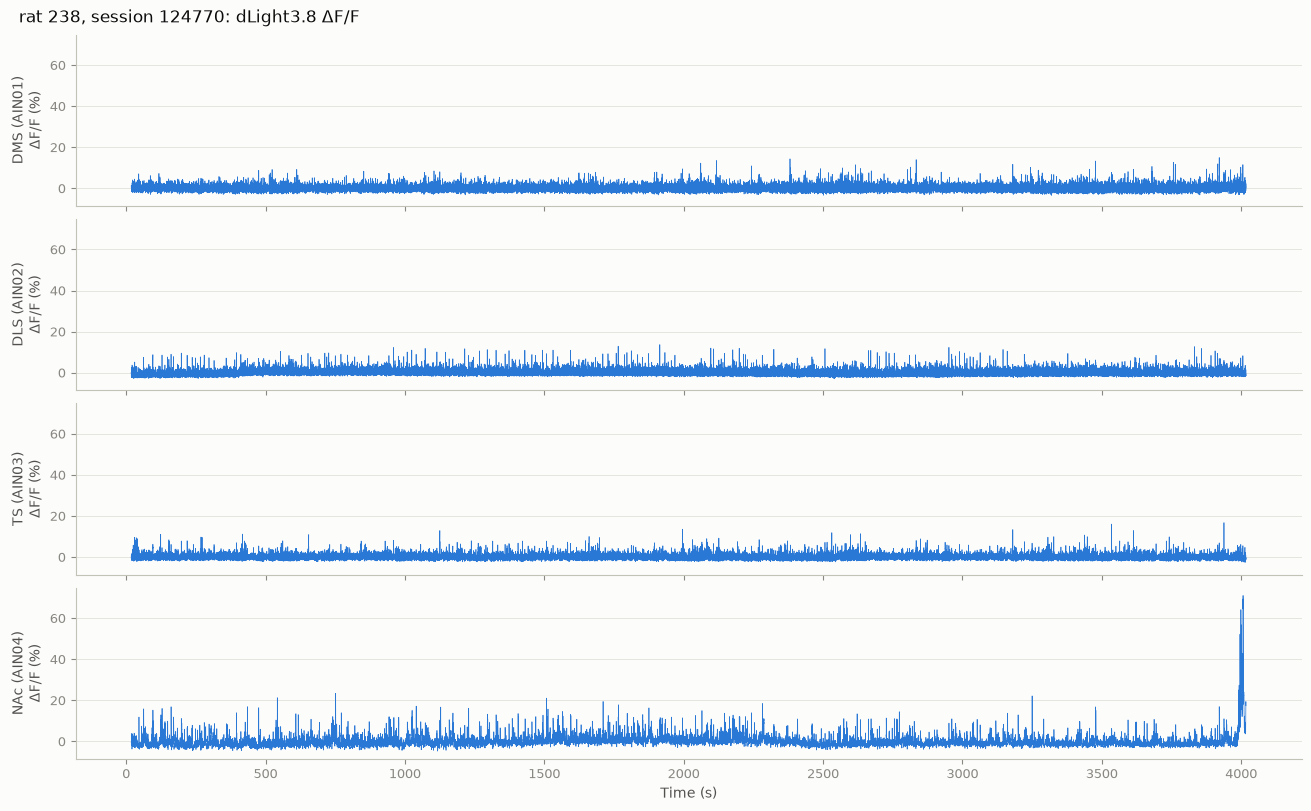

In [12]:
nwb_file_name = first_session
dff = fetch_trace(nwb_file_name, "DFF")
print(f"{session_label(nwb_file_name)}: DFF {dff.shape}, {dff.index[0]:.3f}-{dff.index[-1]:.3f} s")

fig, axes = plt.subplots(4, 1, figsize=(13, 8), sharex=True, sharey=True, constrained_layout=True)
for ax, region in zip(axes, dff.columns):
    ax.plot(dff.index, dff[region], color=SIGNAL_COLOR, lw=0.5, rasterized=True)
    channel = patching.loc[nwb_file_name].eq(region).idxmax()
    ax.set_ylabel(f"{region} ({channel})\nΔF/F (%)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"{session_label(nwb_file_name)}: dLight3.8 ΔF/F", x=0.01, ha="left", color=INK)
plt.show()

### The processing chain for one region

The processed series are successive steps of one pipeline. For one region, the top panel overlays the 10 Hz low-pass filtered signal, its slow-drift baseline, and the fitted isosbestic (the isosbestic trace scaled onto the signal). The fitted isosbestic follows the bleaching and slow artifacts; what the signal does on top of it is dopamine. The bottom panel is the resulting ΔF/F. The window is one minute.

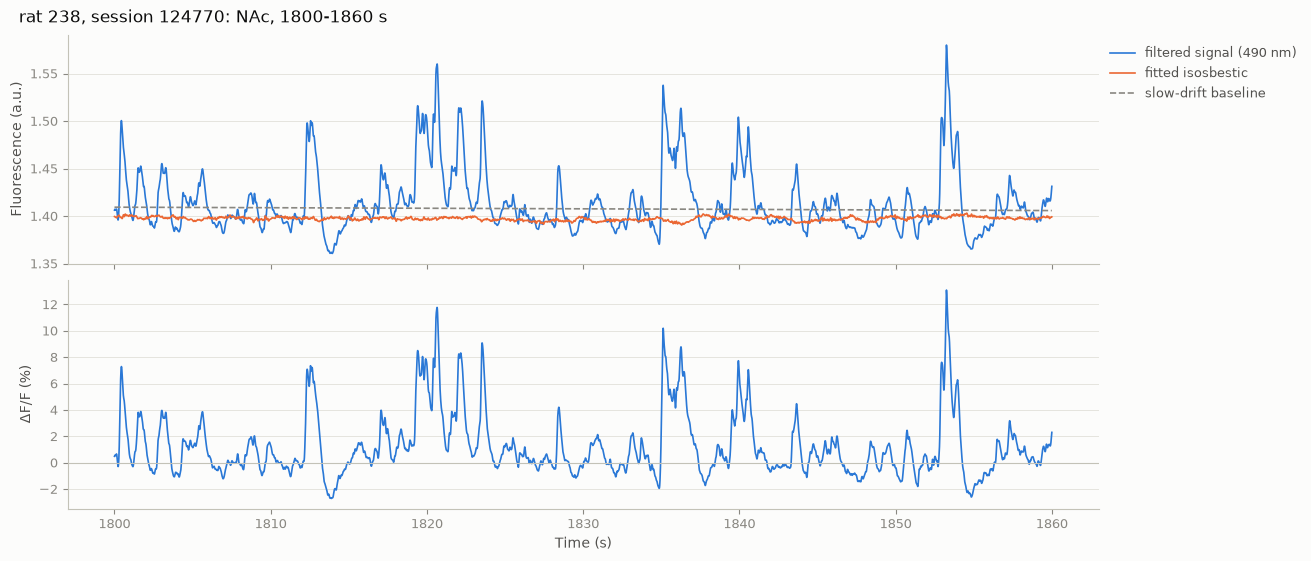

In [13]:
region = "NAc"
window = (1800.0, 1860.0)  # seconds on the session clock

filtered = fetch_trace(nwb_file_name, "FilteredSignal")
baseline = fetch_trace(nwb_file_name, "BaselineSignal")
fitted_iso = fetch_trace(nwb_file_name, "FittedIsosbestic")

sl = slice(*window)
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True, constrained_layout=True)
axes[0].plot(filtered.loc[sl, region], color=SIGNAL_COLOR, lw=1.2, label="filtered signal (490 nm)")
axes[0].plot(fitted_iso.loc[sl, region], color=ISOSBESTIC_COLOR, lw=1.2, label="fitted isosbestic")
axes[0].plot(baseline.loc[sl, region], color=MUTED, lw=1.2, ls="--", label="slow-drift baseline")
axes[0].set_ylabel("Fluorescence (a.u.)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
axes[1].plot(dff.loc[sl, region], color=SIGNAL_COLOR, lw=1.2)
axes[1].axhline(0, color=AXIS, lw=0.8)
axes[1].set_ylabel("ΔF/F (%)")
axes[1].set_xlabel("Time (s)")
fig.suptitle(
    f"{session_label(nwb_file_name)}: {region}, {window[0]:.0f}-{window[1]:.0f} s",
    x=0.01, ha="left", color=INK,
)
plt.show()